# Retrosheet → *The Book*, Recreated — Data Notebook

This notebook is the **data/back-end source of truth** for *The Book, Recreated*:
the project that rebuilds the run-expectancy tables from Tom Tango, Mitchel
Lichtman & Andrew Dolphin's *The Book* using real **Retrosheet** play-by-play data
(1910–2025). It has two jobs:

1. **Teach the pipeline** end to end — Retrosheet event files → Chadwick CSVs →
   additive JSON → the run-expectancy tables the website renders.
2. **Rebuild the datasets** the React site consumes.

## How to use it

| If you want to… | Do this |
|---|---|
| **Explore the numbers** (default) | Run **§1 Setup**, then **§7 Load data & control panel**, then the dashboards in §8–§16 (or just **Run All**). After that you never re-run anything — the §7 control panel drives every chart **live**. |
| **Change what you see** | Use the **control panel in §7** — Seasons / League / Teams / Event. Every dashboard updates automatically. |
| **Rebuild from Retrosheet** | Set `RUN_PIPELINE = True` in §1, then **Run All**. The rebuild section (§3–§6) downloads ~500 MB and runs Chadwick `cwevent` (slow). |

> 📖 **First time?** Read top to bottom. The boring plumbing is bundled into the
> two setup cells (§1 and §7); everything in between and after is either the
> *teaching* of how run expectancy is built or an *interactive dashboard*.

## Map of the notebook

**Setup & concept**
- **§1 — Setup** (run this first): imports, paths/config, constants, helpers
- **§2 — 🧮 The core idea**: run expectancy on a toy half-inning

**The rebuild pipeline** *(optional — only runs when `RUN_PIPELINE = True`)*
- **§3–§6** — download/convert Retrosheet, the aggregators, and the orchestrator

**Explore — 🎛️ interactive** *(driven by the §7 control panel)*
- **§7 — Load data & control panel**
- **§8** — run environment by season
- **§9 — Table 1**: run expectancy by base/out state — *plus a side-by-side with The Book's published figures*
- **§10 — Table 2**: runs to end of inning by event
- **§11 — Tables 3 & 4**: starting RE and run value
- **§12 — Table 5**: one event across all 24 base/out states
- **§13 — Tables 6 & 7**: transition run values
- **§14 — Table 8**: Markov scoring distributions by base/out state
- **§15 — Table 9**: scoring distributions tuned to a chosen runs/game level
- **§16 — Table 10**: win expectancy by inning, score, and base/out state

**Reference**
- **§17** — site sync checkpoint · **§18** — how to add the next table

## 1. Setup — run this first

This single cell loads **everything the rest of the notebook needs**: imports, the
folder paths, the rebuild knobs (`RUN_PIPELINE` etc.), the baseball constants, and
the row-level + aggregation helper functions. Run it once and you're set up.

The detailed *how it's built* material — the Retrosheet/Chadwick field contract and
the per-row translation logic — is documented inline as comments here and exercised
in the rebuild section (§3–§6).

In [17]:
# =============================================================================
# SETUP — run this one cell first.
# Imports, paths/config, baseball constants, and the row-level + aggregation
# helpers used everywhere below. All the boring-but-necessary plumbing lives
# here so the rest of the notebook can stay focused on baseball.
# =============================================================================
from pathlib import Path
from collections import defaultdict
import csv
import json
import re
import shutil
import subprocess
import urllib.request
import zipfile

from IPython.display import Markdown, display
import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
})

# --- Paths & run mode -------------------------------------------------------
CWD = Path.cwd().resolve()
DATABASE_DIR = CWD if CWD.name == "Database" else CWD / "Database"
if not DATABASE_DIR.exists():
    raise RuntimeError("Launch this notebook from the repo root or from Database/.")

REPO_ROOT = DATABASE_DIR.parent
RAW_DIR = DATABASE_DIR / "raw"
OUT_DIR = DATABASE_DIR / "out"
SITE_DATA_DIR = REPO_ROOT / "site" / "src" / "data"
SITE_PUBLIC_DIR = REPO_ROOT / "site" / "public"   # large fetch-at-runtime assets
OUT_DIR.mkdir(parents=True, exist_ok=True)
RAW_DIR.mkdir(parents=True, exist_ok=True)

# Rebuild knobs -- only matter if you run the optional rebuild section (3-6).
START_YEAR = 1910
END_YEAR = 2025
RUN_PIPELINE = False       # True = regenerate datasets from Retrosheet (slow).
COPY_TO_SITE = True
REMOVE_INTERMEDIATE_EVENTS = True
FORCE_DOWNLOAD = False
FORCE_CONVERT = True

# --- Chadwick / Retrosheet contract (used by the rebuild section) -----------
CWEVENT_FIELDS = "0,1,2,3,4,8,9,26,27,28,34,35,38,40,48,58,59,60,61"
CWEVENT_HEADER = [
    "game_id", "vis_team", "inning", "bat_home", "outs", "vis_score", "home_score",
    "r1", "r2", "r3", "event_cd", "bat_event_fl", "sh_fl", "event_outs", "bunt_fl",
    "bat_dest", "r1_dest", "r2_dest", "r3_dest",
]

# --- Baseball constants -----------------------------------------------------
# Base occupancy is a 3-bit mask: 1 = on 1st, 2 = on 2nd, 4 = on 3rd (7 = loaded).
BASE_LABELS = {
    0: "_ _ _", 1: "1B _ _", 2: "_ 2B _", 4: "_ _ 3B",
    3: "1B 2B _", 5: "1B _ 3B", 6: "_ 2B 3B", 7: "1B 2B 3B",
}
BASE_ORDER = [0, 1, 2, 4, 3, 5, 6, 7]
OUTS = (0, 1, 2)

EVENT_CD = {
    23: "HR", 22: "3B", 21: "2B", 20: "1B",
    19: "FC", 18: "RBOE", 17: "INT", 16: "HBP",
    15: "IBB", 14: "NIBB", 13: "FLE", 11: "BK",
    10: "PB", 9: "WP", 8: "PK", 7: "PK",
    6: "CS", 5: "DI", 4: "SB", 3: "K",
}
CATS = [
    ("HR", "Home Run"), ("3B", "Triple"), ("2B", "Double"), ("RBOE", "Error"),
    ("INT", "Interference"), ("SAC", "Sac Bunt"), ("PB", "Passed Ball"),
    ("1B", "Single"), ("WP", "Wild Pitch"), ("HBP", "Hit by Pitch"),
    ("BK", "Balk"), ("NIBB", "Non-Intentional Walk"), ("IBB", "Intentional Walk"),
    ("SB", "Stolen Base"), ("DI", "Defensive Indifference"), ("BUNT", "Bunt"),
    ("PK", "Pickoff"), ("OUT", "Out (on Batted Ball)"), ("K", "Strikeout"),
    ("CS", "Caught Stealing"),
    ("FC", "Fielder's Choice"), ("FLE", "Foul Error"), ("OTHER", "Other"),
]
LABELS = dict(CATS)
CAT_ORDER = [key for key, _ in CATS]

# --- Row-level helpers: translate one Chadwick CSV row -> baseball concepts --
def scored(dest):
    """1 if a batter/runner destination means the player crossed the plate."""
    try:
        return 1 if int(dest) >= 4 else 0   # Chadwick destinations >= 4 == scored
    except ValueError:
        return 0                            # empty / placeholder == did not score


def runs_on_play(row):
    """Count every player who scored on this event."""
    return scored(row["bat_dest"]) + scored(row["r1_dest"]) + scored(row["r2_dest"]) + scored(row["r3_dest"])


def base_state(row):
    """Encode starting base occupancy as the 3-bit mask described above."""
    return (1 if row["r1"] else 0) | (2 if row["r2"] else 0) | (4 if row["r3"] else 0)


def end_base_state(row):
    """Encode base occupancy after the play from Chadwick destination fields."""
    mask = 0
    for field in ("bat_dest", "r1_dest", "r2_dest", "r3_dest"):
        try:
            dest = int(row[field])
        except ValueError:
            continue
        if dest == 1:
            mask |= 1
        elif dest == 2:
            mask |= 2
        elif dest == 3:
            mask |= 4
    return mask


def batting_team(row):
    """The team batting this half-inning (game ids start with the home code)."""
    return row["game_id"][:3] if row["bat_home"] == "1" else row["vis_team"]


def state_key(base, outs):
    """Compact base/out key, matching the React app (base * 10 + outs)."""
    return base * 10 + outs


def eligible_half_inning(half):
    """The Book excludes home halves of the ninth or later, plus partial innings."""
    _game_id, inning, bat_home = half
    return not (bat_home == "1" and int(inning) >= 9)


def event_category(row):
    """Map Retrosheet EVENT_CD into The Book's event categories."""
    cd = int(row["event_cd"])
    if row["bunt_fl"] == "T":               # The Book treats bunts as attempts.
        if base_state(row) and int(row["outs"]) < 2:
            return "SAC"
        return "BUNT"
    if cd == 2:
        return "OUT"
    return EVENT_CD.get(cd, "OTHER")


# --- Site-style aggregation helpers: filter additive groups, divide at the end
def group_matches(group, seasons=None, league="Both", teams=None):
    """Whether one additive (season, team) group belongs in the current selection."""
    if seasons is not None and group["season"] not in seasons:
        return False
    if league != "Both" and group.get("league") != league:
        return False
    if teams is not None and group["team"] not in teams:
        return False
    return True


def selection_label(seasons=None, league="Both", teams=None):
    """Human-readable label for tables and chart titles."""
    season_text = "all seasons" if seasons is None else f"{min(seasons)}-{max(seasons)}" if len(seasons) > 1 else str(next(iter(seasons)))
    team_text = "all teams" if teams is None else f"{len(teams)} teams"
    return f"{season_text}, {league}, {team_text}"


def compute_re_matrix_from_dataset(dataset, seasons=None, league="Both", teams=None):
    """Aggregate the Table 1 run-expectancy matrix for a selection."""
    matrix = {state_key(base, outs): {"base": base, "outs": outs, "count": 0, "sumRuns": 0.0, "re": None} for base in BASE_ORDER for outs in OUTS}
    for group in dataset["groups"]:
        if not group_matches(group, seasons, league, teams):
            continue
        for cell in group["cells"]:
            key = state_key(cell["base"], cell["outs"])
            matrix[key]["count"] += cell["count"]
            matrix[key]["sumRuns"] += cell["sumRuns"]
    for values in matrix.values():
        if values["count"]:
            values["re"] = values["sumRuns"] / values["count"]
    return matrix


def compute_event_totals(dataset, seasons=None, league="Both", teams=None):
    """Aggregate Table 2 event averages for a selection."""
    totals = defaultdict(lambda: {"count": 0, "sumRuns": 0.0})
    for group in dataset["groups"]:
        if not group_matches(group, seasons, league, teams):
            continue
        for cat, cell in group["cells"].items():
            totals[cat]["count"] += cell["count"]
            totals[cat]["sumRuns"] += cell["sumRuns"]
    rows = []
    for cat, values in totals.items():
        count = values["count"]
        avg = values["sumRuns"] / count if count else None
        rows.append({"cat": cat, "Event": LABELS.get(cat, cat), "N": count, "Average": avg})
    return pd.DataFrame(rows).sort_values("Average", ascending=False)


mode = "REBUILD MODE" if RUN_PIPELINE else "EXPLORER MODE"
display(Markdown(
    f"**Setup complete - `{mode}`.** Imports, constants, and helpers loaded - "
    f"data folder `{OUT_DIR}`. "
    + ("The rebuild section (3-6) will regenerate the datasets."
       if RUN_PIPELINE else "Using the existing generated JSON in `out/`.")
))


**Setup complete - `EXPLORER MODE`.** Imports, constants, and helpers loaded - data folder `/Users/rexjensen/Desktop/Tango_book_recreation/Database/out`. Using the existing generated JSON in `out/`.

## 2. 🧮 The core idea: run expectancy on a toy half-inning

Everything downstream rests on one number per play: **how many more runs the team
will score from here to the end of the inning.** For each play that is:

> `runs_to_end = (runs at inning start + total runs scored in the inning) − runs already scored before this play`

The chart below walks one made-up half-inning and shows that number ticking down as
outs accumulate. Then the big idea:

- **Run expectancy of a base/out state (Table 1)** = the *average* `runs_to_end`
  over the thousands of real plate appearances that began in that state.
- **Run value of an event (Tables 2–4)** = how much the average `runs_to_end`
  after the event exceeds the run expectancy of the state it started in.

So this toy inning is the whole project in miniature — §3 onward just runs the same
arithmetic over ~8 million real plays.

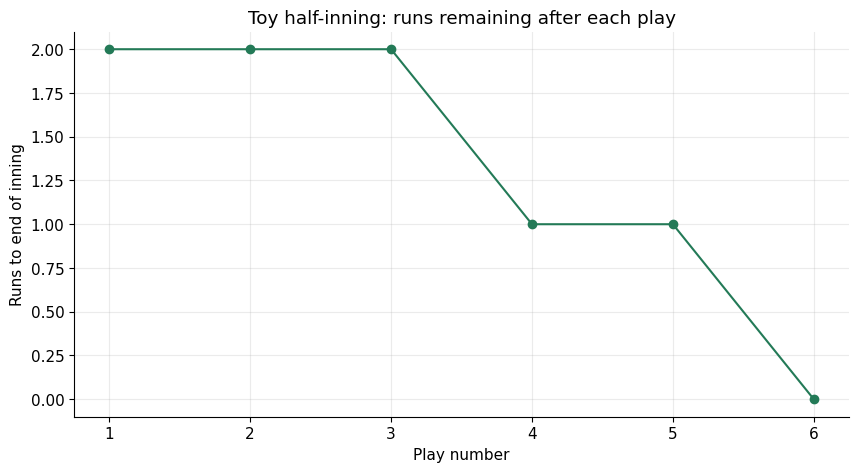

**Toy half-inning total runs:** `2`

,play,runs_before,runs_on_play,base/out start,runs_to_end
0,single,0,0,"empty, 0 out",2
1,walk,0,0,"man on 1st, 0 out",2
2,double,0,1,"1st+2nd, 0 out",2
3,groundout,1,0,"2nd+3rd, 0 out",1
4,sac fly,1,1,"2nd+3rd, 1 out",1
5,strikeout,2,0,"man on 2nd, 2 out",0


In [18]:
toy = pd.DataFrame([
    {"play": "single", "runs_before": 0, "runs_on_play": 0, "base/out start": "empty, 0 out"},
    {"play": "walk", "runs_before": 0, "runs_on_play": 0, "base/out start": "man on 1st, 0 out"},
    {"play": "double", "runs_before": 0, "runs_on_play": 1, "base/out start": "1st+2nd, 0 out"},
    {"play": "groundout", "runs_before": 1, "runs_on_play": 0, "base/out start": "2nd+3rd, 0 out"},
    {"play": "sac fly", "runs_before": 1, "runs_on_play": 1, "base/out start": "2nd+3rd, 1 out"},
    {"play": "strikeout", "runs_before": 2, "runs_on_play": 0, "base/out start": "man on 2nd, 2 out"},
])

inning_start_runs = 0
total_inning_runs = toy["runs_on_play"].sum()
toy["runs_to_end"] = inning_start_runs + total_inning_runs - toy["runs_before"]

fig, ax = plt.subplots()
ax.plot(toy.index + 1, toy["runs_to_end"], marker="o", color="#237a57")
ax.set_title("Toy half-inning: runs remaining after each play")
ax.set_xlabel("Play number")
ax.set_ylabel("Runs to end of inning")
ax.set_xticks(toy.index + 1)
plt.show()

display(Markdown(f"**Toy half-inning total runs:** `{total_inning_runs}`"))
display(toy)

## 3. Rebuild pipeline (optional): download & convert Retrosheet

> The next four sections (§3–§6) define and run the **rebuild pipeline**. They only
> *do* anything when `RUN_PIPELINE = True` (set in §1). In the default Explorer mode
> they just define functions instantly and skip the heavy work — so you can safely
> Run All. **Exploring the existing data? Skip ahead to §7.**

This is the extractor. It downloads missing Retrosheet yearly ZIPs, extracts
`.EVA`/`.EVN` files, and converts them to `out/events_<year>.csv` with Chadwick.
It defines functions but does not download anything until `build_all()` runs.

In [19]:
def ensure_cwevent():
    """Fail early if Chadwick is not installed."""
    if not shutil.which("cwevent"):
        raise RuntimeError("Chadwick is required. Install it with: brew install chadwick")


def season_event_files(year):
    """Return all Retrosheet event files for one season."""
    year_dir = RAW_DIR / str(year)
    return sorted(year_dir.glob(f"{year}*.EVA")) + sorted(year_dir.glob(f"{year}*.EVN"))


def download_and_extract_year(year, force=False):
    """Download a season ZIP from Retrosheet unless the extracted files already exist."""
    year_dir = RAW_DIR / str(year)
    year_dir.mkdir(parents=True, exist_ok=True)
    if season_event_files(year) and not force:
        return

    zip_path = year_dir / f"{year}eve.zip"
    url = f"https://www.retrosheet.org/events/{year}eve.zip"
    print(f"[{year}] downloading {url}")
    urllib.request.urlretrieve(url, zip_path)
    with zipfile.ZipFile(zip_path) as zf:
        zf.extractall(year_dir)
    zip_path.unlink(missing_ok=True)


def write_cwevent_csv(year, force=False):
    """Convert one season of Retrosheet event files into a flat CSV."""
    ensure_cwevent()
    out_path = OUT_DIR / f"events_{year}.csv"
    if out_path.exists() and not force:
        return out_path

    files = season_event_files(year)
    if not files:
        raise FileNotFoundError(f"No Retrosheet event files found for {year} in {RAW_DIR / str(year)}")

    year_dir = RAW_DIR / str(year)
    cmd = ["cwevent", "-y", str(year), "-f", CWEVENT_FIELDS] + [p.name for p in files]
    proc = subprocess.run(cmd, cwd=year_dir, text=True, capture_output=True)
    if proc.returncode != 0:
        print(proc.stderr.strip())
        raise RuntimeError(f"cwevent failed for {year} with exit code {proc.returncode}")

    with out_path.open("w", newline="") as f:
        writer = csv.writer(f, lineterminator="\n")
        writer.writerow(CWEVENT_HEADER)
        f.write(proc.stdout)
    return out_path


def team_league_rows_for_year(year):
    """The file extension tells us the home team's league for that season."""
    for path in sorted((RAW_DIR / str(year)).glob(f"{year}*.EVA")):
        yield [year, path.name[4:7], "AL"]
    for path in sorted((RAW_DIR / str(year)).glob(f"{year}*.EVN")):
        yield [year, path.name[4:7], "NL"]


def build_event_csvs(start_year=START_YEAR, end_year=END_YEAR, force_download=FORCE_DOWNLOAD, force_convert=FORCE_CONVERT):
    """Build all intermediate event CSVs plus the season/team league map."""
    OUT_DIR.mkdir(parents=True, exist_ok=True)
    team_league_path = OUT_DIR / "team_league_all.csv"
    with team_league_path.open("w", newline="") as league_file:
        league_writer = csv.writer(league_file, lineterminator="\n")
        for year in range(start_year, end_year + 1):
            download_and_extract_year(year, force=force_download)
            csv_path = write_cwevent_csv(year, force=force_convert)
            league_writer.writerows(team_league_rows_for_year(year))
            event_count = sum(1 for _ in csv_path.open()) - 1
            print(f"[{year}] {event_count:,} converted events")
    return team_league_path

extractor_summary = pd.DataFrame([
    ("download_and_extract_year", "Gets missing Retrosheet ZIPs and extracts event files."),
    ("write_cwevent_csv", "Runs Chadwick cwevent and writes out/events_<year>.csv."),
    ("build_event_csvs", "Loops seasons and writes team_league_all.csv."),
], columns=["Function", "Purpose"])

display(Markdown("**Extractor functions are defined. No network/download work has run yet.**"))
display(extractor_summary)

**Extractor functions are defined. No network/download work has run yet.**

,Function,Purpose
0,download_and_extract_year,Gets missing Retrosheet ZIPs and extracts even...
1,write_cwevent_csv,Runs Chadwick cwevent and writes out/events_<y...
2,build_event_csvs,Loops seasons and writes team_league_all.csv.


## 4. Rebuild pipeline: Table 1 run-expectancy aggregator

This cell defines the Table 1 builder. The important filters are:

- only complete half-innings ending with exactly three outs
- only plate appearances for Table 1
- additive output by `(season, team)` so the site can filter without reprocessing play-by-play

In [20]:
def load_team_league():
    """Load the season/team -> league lookup produced during extraction."""
    mapping = {}
    with (OUT_DIR / "team_league_all.csv").open() as f:
        for line in f:
            season, team, league = line.strip().split(",")
            mapping[(int(season), team)] = league
    return mapping


def event_csv_paths():
    """Find intermediate event CSVs currently available on disk."""
    return sorted(OUT_DIR.glob("events_*.csv"))


def season_from_events_path(path):
    """Extract the four-digit season from out/events_YYYY.csv."""
    return int(re.search(r"events_(\d{4})\.csv", path.name).group(1))


def process_re_season(path, season, groups, overall_by_season):
    """Accumulate Table 1 counts and run totals for one season."""
    rows = []
    inn_runs_start = {}
    inn_runs_total = defaultdict(int)
    inn_outs_total = defaultdict(int)

    with path.open(newline="") as f:
        for row in csv.DictReader(f):
            half = (row["game_id"], row["inning"], row["bat_home"])
            runs_before = int(row["vis_score"]) + int(row["home_score"])

            # The first row seen for a half-inning gives the score at inning start.
            if half not in inn_runs_start:
                inn_runs_start[half] = runs_before

            # These totals let us decide later whether the half-inning completed normally.
            inn_runs_total[half] += runs_on_play(row)
            inn_outs_total[half] += int(row["event_outs"])

            # Store just enough information to compute runs-to-end after inning totals are known.
            rows.append((half, runs_before, base_state(row), int(row["outs"]), row["bat_event_fl"] == "T", batting_team(row)))

    used_halves = set()
    for half, runs_before, base, outs, is_pa, team in rows:
        if not eligible_half_inning(half) or inn_outs_total[half] != 3 or not is_pa:
            continue
        runs_roi = (inn_runs_start[half] + inn_runs_total[half]) - runs_before
        cell = (base, outs)
        groups[(season, team)][cell][0] += 1
        groups[(season, team)][cell][1] += runs_roi
        overall_by_season[season][cell][0] += 1
        overall_by_season[season][cell][1] += runs_roi
        used_halves.add(half)
    return len(used_halves)


def write_re_matrix(season, overall):
    """Write a human-readable 8x3 CSV for one season."""
    path = OUT_DIR / f"re_matrix_{season}.csv"
    with path.open("w", newline="") as f:
        writer = csv.writer(f, lineterminator="\n")
        writer.writerow(["bases", "0 outs", "1 out", "2 outs", "n_0", "n_1", "n_2"])
        for base in BASE_ORDER:
            vals, counts = [], []
            for outs in OUTS:
                count, sum_runs = overall[(base, outs)]
                vals.append(f"{sum_runs / count:.3f}" if count else "")
                counts.append(count)
            writer.writerow([BASE_LABELS[base]] + vals + counts)
    return path


def build_re_dataset():
    """Build Database/out/re_dataset.json for the site."""
    team_league = load_team_league()
    groups = defaultdict(lambda: defaultdict(lambda: [0, 0.0]))
    overall_by_season = defaultdict(lambda: defaultdict(lambda: [0, 0.0]))
    seasons = []

    for path in event_csv_paths():
        season = season_from_events_path(path)
        seasons.append(season)
        complete = process_re_season(path, season, groups, overall_by_season)
        count, sum_runs = overall_by_season[season][(0, 0)]
        print(f"{season}: {complete:,} complete innings, empty/0-out RE = {sum_runs / count:.3f}")
    seasons.sort()

    for season in seasons:
        write_re_matrix(season, overall_by_season[season])

    group_list = []
    for (season, team) in sorted(groups):
        cells = []
        for base in BASE_ORDER:
            for outs in OUTS:
                count, sum_runs = groups[(season, team)][(base, outs)]
                cells.append({"base": base, "outs": outs, "count": count, "sumRuns": round(sum_runs, 4)})
        group_list.append({"season": season, "team": team, "league": team_league.get((season, team), "?"), "cells": cells})

    dataset = {
        "meta": {
            "title": "Run Expectancy by the 24 Base/Out States",
            "source": "Retrosheet event files parsed with Chadwick cwevent, computed locally",
            "method": "mean runs scored to end of inning, per plate appearance; complete (3-out) innings only; excludes home halves of the ninth or later",
            "seasons": seasons,
            "baseLabels": {str(k): v for k, v in BASE_LABELS.items()},
            "baseOrder": BASE_ORDER,
        },
        "groups": group_list,
    }
    with (OUT_DIR / "re_dataset.json").open("w") as f:
        json.dump(dataset, f, separators=(",", ":"))
    return dataset

re_builder_summary = pd.DataFrame([
    ("Input", "out/events_<year>.csv"),
    ("Output", "out/re_dataset.json and out/re_matrix_<year>.csv"),
    ("Unit of additivity", "season + batting team + base/out state"),
    ("Main filter", "complete 3-out half-innings; plate appearances only"),
], columns=["Topic", "Value"])

display(Markdown("**Table 1 aggregator functions are defined.**"))
display(re_builder_summary)

**Table 1 aggregator functions are defined.**

,Topic,Value
0,Input,out/events_<year>.csv
1,Output,out/re_dataset.json and out/re_matrix_<year>.csv
2,Unit of additivity,season + batting team + base/out state
3,Main filter,complete 3-out half-innings; plate appearances...


## 5. Rebuild pipeline: event tables and event starting states

Tables 2-11 need event-level and transition data. This cell builds three datasets:

- `event_dataset.json`: event -> count and runs-to-end totals
- `event_states.json`: event -> starting base/out distribution, event start->end transitions, and all-event Markov transition counts for Tables 8-10
- `win_events.json`: all-game event start->end game-state transitions for Table 11 win values; unlike run values, it keeps partial innings, walk-offs, and home ninth/later events


In [21]:
def process_event_season(path, season, groups):
    """Accumulate runs-to-end totals by event type for one season."""
    rows = []
    inn_runs_start = {}
    inn_runs_total = defaultdict(int)
    inn_outs_total = defaultdict(int)

    with path.open(newline="") as f:
        for row in csv.DictReader(f):
            half = (row["game_id"], row["inning"], row["bat_home"])
            runs_before = int(row["vis_score"]) + int(row["home_score"])
            if half not in inn_runs_start:
                inn_runs_start[half] = runs_before
            inn_runs_total[half] += runs_on_play(row)
            inn_outs_total[half] += int(row["event_outs"])
            rows.append((half, runs_before, event_category(row), batting_team(row)))

    for half, runs_before, cat, team in rows:
        if not eligible_half_inning(half) or inn_outs_total[half] != 3:
            continue
        runs_roi = (inn_runs_start[half] + inn_runs_total[half]) - runs_before
        groups[(season, team)][cat][0] += 1
        groups[(season, team)][cat][1] += runs_roi


def write_event_table(season, totals):
    """Write a human-readable event table for one season."""
    path = OUT_DIR / f"re_by_event_{season}.csv"
    rows = []
    for cat in CAT_ORDER:
        count, sum_runs = totals.get(cat, (0, 0.0))
        if count:
            rows.append((LABELS[cat], cat, count, round(sum_runs, 1), sum_runs / count))
    rows.sort(key=lambda row: row[4], reverse=True)

    with path.open("w", newline="") as f:
        writer = csv.writer(f, lineterminator="\n")
        writer.writerow(["Event", "code", "N", "Runs to End of Inning", "Average Runs"])
        for label, cat, count, sum_runs, avg in rows:
            writer.writerow([label, cat, count, sum_runs, f"{avg:.3f}"])
    return path, rows


def build_event_dataset():
    """Build Database/out/event_dataset.json."""
    team_league = load_team_league()
    groups = defaultdict(lambda: defaultdict(lambda: [0, 0.0]))
    seasons = []
    for path in event_csv_paths():
        season = season_from_events_path(path)
        seasons.append(season)
        process_event_season(path, season, groups)
    seasons.sort()

    season_totals = defaultdict(lambda: defaultdict(lambda: [0, 0.0]))
    for (season, team), cats in groups.items():
        for cat, (count, sum_runs) in cats.items():
            season_totals[season][cat][0] += count
            season_totals[season][cat][1] += sum_runs
    for season in seasons:
        write_event_table(season, {key: tuple(value) for key, value in season_totals[season].items()})

    group_list = []
    for (season, team) in sorted(groups):
        cells = {cat: {"count": count, "sumRuns": round(sum_runs, 4)} for cat, (count, sum_runs) in groups[(season, team)].items()}
        group_list.append({"season": season, "team": team, "league": team_league.get((season, team), "?"), "cells": cells})

    dataset = {"meta": {"title": "Runs To End Of Inning, By Event", "source": "Retrosheet event files parsed with Chadwick cwevent, computed locally", "method": "mean runs scored to end of inning, over every occurrence of the event; complete (3-out) innings only; excludes home halves of the ninth or later", "seasons": seasons, "categories": CATS}, "groups": group_list}
    with (OUT_DIR / "event_dataset.json").open("w") as f:
        json.dump(dataset, f, separators=(",", ":"))
    return dataset


def process_event_state_season(path, season, groups, markov_groups):
    """Accumulate event totals, event transitions, and all-event Markov transitions."""
    rows = []
    inn_runs_start = {}
    inn_runs_total = defaultdict(int)
    inn_outs_total = defaultdict(int)

    with path.open(newline="") as f:
        for row in csv.DictReader(f):
            half = (row["game_id"], row["inning"], row["bat_home"])
            runs_before = int(row["vis_score"]) + int(row["home_score"])
            start_outs = int(row["outs"])
            play_outs = int(row["event_outs"])
            end_outs = min(3, start_outs + play_outs)
            start_key = state_key(base_state(row), start_outs)
            # Once the play records the third out, the inning is over; remaining base
            # occupancy no longer has run expectancy, so all third-out transitions share key 3.
            end_key = state_key(end_base_state(row), end_outs) if end_outs < 3 else state_key(0, 3)
            scored_on_play = runs_on_play(row)

            if half not in inn_runs_start:
                inn_runs_start[half] = runs_before
            inn_runs_total[half] += scored_on_play
            inn_outs_total[half] += play_outs
            rows.append((
                half,
                runs_before,
                event_category(row),
                batting_team(row),
                start_key,
                end_key,
                scored_on_play,
            ))

    for half, runs_before, cat, team, start_key, end_key, scored_on_play in rows:
        if not eligible_half_inning(half) or inn_outs_total[half] != 3:
            continue
        runs_roi = (inn_runs_start[half] + inn_runs_total[half]) - runs_before
        event = groups[(season, team)][cat]
        event["count"] += 1
        event["sumRuns"] += runs_roi
        event["states"][start_key][0] += 1
        event["states"][start_key][1] += runs_roi
        transition_key = f"{start_key}>{end_key}"
        event["transitions"][transition_key][0] += 1
        event["transitions"][transition_key][1] += scored_on_play
        markov_key = f"{start_key}>{end_key}|{min(5, scored_on_play)}"
        markov_groups[(season, team)][markov_key] += 1


def build_event_states_dataset():
    """Build Database/out/event_states.json for Tables 2-9 on the site."""
    team_league = load_team_league()
    def new_event():
        return {
            "count": 0,
            "sumRuns": 0.0,
            "states": defaultdict(lambda: [0, 0]),
            "transitions": defaultdict(lambda: [0, 0]),
        }

    groups = defaultdict(lambda: defaultdict(new_event))
    markov_groups = defaultdict(lambda: defaultdict(int))
    seasons = []
    for path in event_csv_paths():
        season = season_from_events_path(path)
        seasons.append(season)
        process_event_state_season(path, season, groups, markov_groups)
    seasons.sort()

    group_list = []
    for (season, team) in sorted(groups):
        events = {}
        for cat, event in groups[(season, team)].items():
            events[cat] = {
                "count": event["count"],
                "sumRuns": round(event["sumRuns"], 4),
                "states": {
                    str(skey): [count, int(sum_runs)]
                    for skey, (count, sum_runs) in sorted(event["states"].items())
                },
                "transitions": {
                    key: [count, int(scored)]
                    for key, (count, scored) in sorted(event["transitions"].items())
                },
            }
        markov = {key: count for key, count in sorted(markov_groups[(season, team)].items())}
        group_list.append({"season": season, "team": team, "league": team_league.get((season, team), "?"), "events": events, "markov": markov})

    dataset = {
        "meta": {
            "title": "Event Run Expectancy States and Transitions",
            "source": "Retrosheet event files parsed with Chadwick cwevent, computed locally",
            "method": "for every occurrence of an event, stores the starting base/out state and the start-to-end transition with runs scored on the play; also stores all-event transition counts by runs scored on the play for Markov scoring distributions and run-environment adjustments; complete (3-out) innings only; excludes home halves of the ninth or later",
            "seasons": seasons,
            "categories": CATS,
        },
        "groups": group_list,
    }
    with (OUT_DIR / "event_states.json").open("w") as f:
        json.dump(dataset, f, separators=(",", ":"))
    return dataset



def win_state_from_row(row):
    """Compact game state before a play: inning, half, score, and base/out."""
    inning = min(9, int(row["inning"]))
    half = "B" if row["bat_home"] == "1" else "T"
    diff = int(row["home_score"]) - int(row["vis_score"])
    key = state_key(base_state(row), int(row["outs"]))
    return f"{inning}|{half}|{diff}|{key}"


def terminal_state(final_vis, final_home):
    """Terminal state from the home team's point of view."""
    if final_home > final_vis:
        return "W"
    if final_home < final_vis:
        return "L"
    return "T"


def encode_win_transitions(counter, state_to_id):
    """Encode sorted transition counts as small deltas to keep win_events.json under GitHub's file limit."""
    triples = []
    for (start, end), count in counter.items():
        triples.append((state_to_id[start], state_to_id[end], count))
    triples.sort()

    encoded = []
    prev_start = 0
    prev_end = 0
    for start, end, count in triples:
        start_delta = start - prev_start
        if start_delta:
            prev_end = 0
        encoded.extend([start_delta, end - prev_end, count])
        prev_start = start
        prev_end = end
    return encoded


def process_win_event_season(path, season, groups, states, state_to_id):
    """Accumulate all-game event game-state transitions for one season."""
    game_rows = defaultdict(list)
    final_scores = {}

    with path.open(newline="") as f:
        for row in csv.DictReader(f):
            game_id = row["game_id"]
            scored = runs_on_play(row)
            vis_after = int(row["vis_score"]) + (0 if row["bat_home"] == "1" else scored)
            home_after = int(row["home_score"]) + (scored if row["bat_home"] == "1" else 0)
            final_scores[game_id] = (vis_after, home_after)
            game_rows[game_id].append({
                "team": batting_team(row),
                "cat": event_category(row),
                "start": win_state_from_row(row),
            })

    for game_id, rows in game_rows.items():
        final_vis, final_home = final_scores[game_id]
        for i, item in enumerate(rows):
            start = item["start"]
            end = rows[i + 1]["start"] if i + 1 < len(rows) else terminal_state(final_vis, final_home)
            for state in (start, end):
                if state not in state_to_id:
                    state_to_id[state] = len(states)
                    states.append(state)
            groups[(season, item["team"])][item["cat"]][(start, end)] += 1


def build_win_events_dataset():
    """Build Database/out/win_events.json for Table 11 on the site."""
    team_league = load_team_league()
    states = ["W", "L", "T"]
    state_to_id = {state: i for i, state in enumerate(states)}
    groups = defaultdict(lambda: defaultdict(lambda: defaultdict(int)))
    seasons = []

    for path in event_csv_paths():
        season = season_from_events_path(path)
        seasons.append(season)
        process_win_event_season(path, season, groups, states, state_to_id)
    seasons.sort()

    event_names = sorted({cat for events in groups.values() for cat in events})
    event_ids = {cat: i for i, cat in enumerate(event_names)}
    group_list = []
    for (season, team) in sorted(groups):
        events = []
        for cat, transitions in sorted(groups[(season, team)].items()):
            count = sum(transitions.values())
            events.append([event_ids[cat], count, encode_win_transitions(transitions, state_to_id)])
        group_list.append([season, team, team_league.get((season, team), "?"), events])

    dataset = {
        "meta": {
            "title": "Win Value Event Game States",
            "source": "Retrosheet event files parsed with Chadwick cwevent, computed locally",
            "method": "for every event occurrence, stores the starting game state and ending game state for win-value calculations; includes partial innings, walk-offs, and home halves of the ninth or later",
            "seasons": seasons,
            "categories": CATS,
            "schema": "win-event-transitions-v4",
            "groupFormat": "[season,team,league,events]",
            "eventFormat": "[eventId,count,flatTransitions]",
            "stateFormat": "states[id] is W/L/T or inning|half(T/B)|home_score_diff|base_out_key",
            "transitionFormat": "flatTransitions are repeating startStateDelta,endStateDelta,count triples sorted by start/end; reset previous end to 0 whenever start delta is nonzero",
        },
        "events": event_names,
        "states": states,
        "groups": group_list,
    }
    with (OUT_DIR / "win_events.json").open("w") as f:
        json.dump(dataset, f, separators=(",", ":"))
    return dataset

event_builder_summary = pd.DataFrame([
    ("event_dataset.json", "Table 2 standalone event averages"),
    ("event_states.json", "Tables 2-10 on the deployed site"),
    ("win_events.json", "Table 11 all-game win values on the deployed site"),
    ("State payload", "[count, sumRuns] by start state, event start->end transitions, plus Markov transition counts"),
    ("Win payload", "compact all-game start->end game-state transition counts by event"),
], columns=["Output", "Why it exists"])

display(Markdown("**Event aggregators are defined.**"))
display(event_builder_summary)


**Event aggregators are defined.**

,Output,Why it exists
0,event_dataset.json,Table 2 standalone event averages
1,event_states.json,Tables 2-6 on the deployed site
2,State payload,"[count, sumRuns] per event and starting base/o..."


## 6. Rebuild orchestrator

This wires the extractor and aggregators together. If `RUN_PIPELINE` is `False`
(the default), it does nothing destructive and just reports Explorer mode.

In [22]:
def sync_site_data(files=("re_dataset.json", "event_states.json", "win_events.json")):
    """Copy the generated JSON the React site uses.

    re_dataset.json is imported as a module (small, needed synchronously), so it
    lives in site/src/data/. event_states.json and win_events.json are large over all
    Retrosheet seasons and are fetched at runtime, so they live in site/public/
    and are served as static assets (keeps them out of Vite's bundle/heap).
    """
    # Per-file destination: anything not listed defaults to src/data.
    dest_dir = {"event_states.json": SITE_PUBLIC_DIR, "win_events.json": SITE_PUBLIC_DIR}
    SITE_DATA_DIR.mkdir(parents=True, exist_ok=True)
    SITE_PUBLIC_DIR.mkdir(parents=True, exist_ok=True)
    copied = []
    for name in files:
        src = OUT_DIR / name
        dst = dest_dir.get(name, SITE_DATA_DIR) / name
        if not src.exists():
            raise FileNotFoundError(f"Cannot sync missing dataset: {src}")
        shutil.copy2(src, dst)
        copied.append(dst)
    return copied


def remove_intermediate_event_csvs():
    """Delete large regenerable event CSVs after JSON has been built."""
    removed = []
    for path in event_csv_paths():
        path.unlink()
        removed.append(path)
    return removed


def build_all(start_year=START_YEAR, end_year=END_YEAR, copy_to_site=COPY_TO_SITE, remove_intermediate_events=REMOVE_INTERMEDIATE_EVENTS, force_download=FORCE_DOWNLOAD, force_convert=FORCE_CONVERT):
    """Run the full Retrosheet -> JSON -> site-data pipeline."""
    build_event_csvs(start_year=start_year, end_year=end_year, force_download=force_download, force_convert=force_convert)
    re_data = build_re_dataset()
    event_data = build_event_dataset()
    state_data = build_event_states_dataset()
    win_data = build_win_events_dataset()
    copied = sync_site_data() if copy_to_site else []
    removed = remove_intermediate_event_csvs() if remove_intermediate_events else []
    return {"re_groups": len(re_data["groups"]), "event_groups": len(event_data["groups"]), "state_groups": len(state_data["groups"]), "win_groups": len(win_data["groups"]), "copied": copied, "removed_csvs": len(removed)}

if RUN_PIPELINE:
    rebuild_result = build_all()
    rebuild_df = pd.DataFrame([(k, str(v)) for k, v in rebuild_result.items()], columns=["Result", "Value"])
    display(Markdown("**Rebuild complete.**"))
    display(rebuild_df)
else:
    rebuild_df = pd.DataFrame([
        ("Mode", "Explorer mode"),
        ("Action", "Skipped full Retrosheet rebuild"),
        ("To rebuild", "Set RUN_PIPELINE = True in section 2, then run all cells"),
    ], columns=["Setting", "Value"])
    display(Markdown("**Pipeline not run. Existing generated JSON will be used below.**"))
    display(rebuild_df)


**Pipeline not run. Existing generated JSON will be used below.**

,Setting,Value
0,Mode,Explorer mode
1,Action,Skipped full Retrosheet rebuild
2,To rebuild,"Set RUN_PIPELINE = True in section 2, then run..."


## 7. Load data & control panel — your one stop for exploring

This cell reads the three generated JSON datasets and builds the **filter panel**
that drives every dashboard below. Thanks to `ipywidgets.interactive_output`, the
charts in §9–§12 re-render **live** whenever you change a control — no manual cell
reruns.

- **Teams** empty = all teams. **League** = AL / NL / Both. **Event** only affects §12.
- **Reset filters** returns to the full 1910–2025 / all-teams / HR view.

> If your environment can't render widgets (e.g. a plain `nbconvert` run), the
> dashboards still execute once with the default selection, so you always see output.

In [23]:
# =============================================================================
# LOAD DATA + CONTROL PANEL
# Reads the generated JSON and builds the filters that drive every dashboard
# below (live, via ipywidgets.interactive_output).
# =============================================================================
def read_json(name):
    """Load one generated dataset from Database/out."""
    path = OUT_DIR / name
    if not path.exists():
        raise FileNotFoundError(f"Missing {path}. Run the rebuild section (3-6) with RUN_PIPELINE = True first.")
    with path.open() as f:
        return json.load(f)

re_dataset = read_json("re_dataset.json")
event_dataset = read_json("event_dataset.json")
event_states = read_json("event_states.json")
win_events = read_json("win_events.json")

all_seasons = tuple(re_dataset["meta"]["seasons"])
all_teams = sorted({group["team"] for group in re_dataset["groups"]})
all_events = [code for code, _ in CATS]

season_widget = widgets.SelectMultiple(options=all_seasons, value=all_seasons, description="Seasons", rows=10)
league_widget = widgets.Dropdown(options=["Both", "AL", "NL"], value="Both", description="League")
team_widget = widgets.SelectMultiple(options=all_teams, value=tuple(), description="Teams", rows=10)
event_widget = widgets.Dropdown(options=[(LABELS.get(code, code), code) for code in all_events], value="HR", description="Event")

reset_button = widgets.Button(description="Reset filters", icon="undo", button_style="warning")
def _reset_filters(_):
    season_widget.value = all_seasons
    league_widget.value = "Both"
    team_widget.value = tuple()
    event_widget.value = "HR"
reset_button.on_click(_reset_filters)

# One shared control set. Every dashboard binds to these widgets via
# interactive_output, so editing any control re-renders the charts live.
CONTROLS = {"seasons": season_widget, "league": league_widget, "teams": team_widget}
CONTROLS_EVENT = dict(CONTROLS, event=event_widget)


def read_selection():
    """Live snapshot of the control panel as plain Python values."""
    seasons = set(season_widget.value) or set(all_seasons)
    league = league_widget.value
    teams = set(team_widget.value) if team_widget.value else None
    event = event_widget.value
    return seasons, league, teams, event


def normalize(seasons, teams):
    """Turn raw widget values (tuples) into the (set | None) shapes helpers expect."""
    return (set(seasons) or set(all_seasons)), (set(teams) or None)


def current_selection(use_widgets=True):   # backwards-compatible alias
    return read_selection()


panel = widgets.VBox([
    widgets.HTML("<b>Filters</b> &mdash; empty <i>Teams</i> means all teams. "
                 "Every dashboard below updates live as you change these."),
    widgets.HBox([season_widget, team_widget]),
    widgets.HBox([league_widget, event_widget]),
    reset_button,
])


def show_selection(seasons, league, teams, event):
    """Live readout of the current filter."""
    seasons, teams = normalize(seasons, teams)
    df = pd.DataFrame([
        ("Seasons", f"{min(seasons)}-{max(seasons)} ({len(seasons)} of {len(all_seasons)})"),
        ("League", league),
        ("Teams", "All teams" if teams is None else ", ".join(sorted(teams))),
        ("Event (Table 5 only)", f"{event} - {LABELS.get(event, event)}"),
    ], columns=["Filter", "Current value"])
    display(df)

display(Markdown(f"**Loaded {len(re_dataset['groups'])} (season, team) groups, "
                 f"{min(all_seasons)}-{max(all_seasons)}.** Set your filters below, then read on."))
display(panel)
display(widgets.interactive_output(show_selection, CONTROLS_EVENT))


**Loaded 1318 (season, team) groups, 1980-2025.** Set your filters below, then read on.

Output()

## 8. Run environment by season

The empty-bases / zero-outs run expectancy is the expected runs at the start of an
inning — a compact proxy for the run environment. This chart always shows all
seasons, split into overall MLB plus AL and NL, so you can see the offensive era
in context.

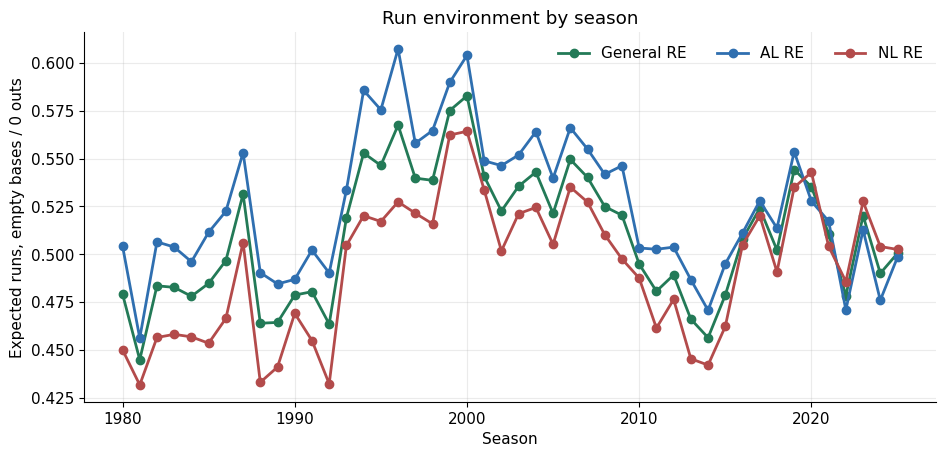

**Season-level run environment table**

,Season,General RE,AL RE,NL RE
36,2016,0.508017,0.511093,0.504929
37,2017,0.524037,0.527938,0.520119
38,2018,0.502217,0.513689,0.490781
39,2019,0.544311,0.553621,0.535007
40,2020,0.535278,0.527785,0.542872
41,2021,0.510748,0.517286,0.504175
42,2022,0.478341,0.470949,0.485736
43,2023,0.520213,0.512803,0.527628
44,2024,0.490061,0.475996,0.504070
45,2025,0.500531,0.498527,0.502546


In [24]:
season_points = []
league_series = [("Both", "General RE"), ("AL", "AL RE"), ("NL", "NL RE")]
for season in all_seasons:
    row = {"Season": season}
    for league, label in league_series:
        matrix = compute_re_matrix_from_dataset(re_dataset, seasons={season}, league=league)
        row[label] = matrix[state_key(0, 0)]["re"]
    season_points.append(row)
season_re_df = pd.DataFrame(season_points)

fig, ax = plt.subplots(figsize=(11, 4.8))
colors = {"General RE": "#237a57", "AL RE": "#2f6fb0", "NL RE": "#b34b4b"}
for label in ["General RE", "AL RE", "NL RE"]:
    ax.plot(season_re_df["Season"], season_re_df[label], color=colors[label], marker="o", linewidth=2, label=label)
ax.set_title("Run environment by season")
ax.set_xlabel("Season")
ax.set_ylabel("Expected runs, empty bases / 0 outs")
ax.legend(frameon=False, ncol=3)
plt.show()

display(Markdown("**Season-level run environment table**"))
display(season_re_df.tail(10))

## 9. Table 1 — run expectancy by base/out state 🎛️

The 24-state matrix: the average number of runs scored from each base/out state to
the end of the inning. It should be **monotonic** — adding runners or removing outs
can only raise run expectancy — and the cell prints a quick sanity check confirming
it for the current selection.

The second table puts our numbers **side by side with the figures published in
*The Book*** (1999–2002 data). Ours run a touch lower because 1999–2002 was a
higher-offense era — narrow the **Seasons** filter to 1999–2002 in the control panel
and watch the gap shrink.

In [16]:
# Run expectancy as published in The Book (Tango/Lichtman/Dolphin), 1999-2002 data.
# Keyed by base bitmask -> (0 out, 1 out, 2 out). Reference values for comparison only.
BOOK_1999_2002_RE = {
    0: (0.555, 0.297, 0.117),  # bases empty
    1: (0.953, 0.573, 0.251),  # 1B
    2: (1.189, 0.725, 0.344),  # 2B
    4: (1.482, 0.983, 0.387),  # 3B
    3: (1.573, 0.971, 0.466),  # 1B 2B
    5: (1.904, 1.243, 0.538),  # 1B 3B
    6: (2.052, 1.467, 0.634),  # 2B 3B
    7: (2.417, 1.650, 0.815),  # bases loaded
}


def render_table1(seasons, league, teams):
    """Heatmap + table of the 24-state run-expectancy matrix for the current filter."""
    seasons, teams = normalize(seasons, teams)
    matrix = compute_re_matrix_from_dataset(re_dataset, seasons, league, teams)

    out_cols = ["0 outs", "1 out", "2 outs"]
    re_rows = []
    for base in BASE_ORDER:
        row = {"Bases": BASE_LABELS[base]}
        for outs, col in zip(OUTS, out_cols):
            row[col] = matrix[state_key(base, outs)]["re"]
            row[f"N ({col})"] = matrix[state_key(base, outs)]["count"]
        re_rows.append(row)
    re_table = pd.DataFrame(re_rows)
    heat_values = re_table[out_cols]

    fig, ax = plt.subplots(figsize=(7, 5.5))
    im = ax.imshow(heat_values, cmap="Greens", aspect="auto")
    ax.set_xticks(range(3), out_cols)
    ax.set_yticks(range(len(BASE_ORDER)), [BASE_LABELS[b] for b in BASE_ORDER])
    ax.set_title(f"Table 1 run expectancy — {selection_label(seasons, league, teams)}")
    for i in range(len(BASE_ORDER)):
        for j in range(3):
            value = heat_values.iloc[i, j]
            ax.text(j, i, "-" if pd.isna(value) else f"{value:.3f}", ha="center", va="center", color="black")
    fig.colorbar(im, ax=ax, label="Expected runs to end of inning")
    plt.show()

    # Sanity checks: RE must fall as outs rise, and the worst state must beat empty/0-out.
    re_of = lambda b, o: matrix[state_key(b, o)]["re"] or 0.0
    outs_monotonic = all(re_of(b, 0) >= re_of(b, 1) >= re_of(b, 2) for b in BASE_ORDER)
    loaded_beats_empty = re_of(7, 0) > re_of(0, 0)
    check = "✅" if (outs_monotonic and loaded_beats_empty) else "⚠️"
    display(Markdown(
        f"{check} **Sanity:** RE falls as outs rise in every row: `{outs_monotonic}` · "
        f"loaded/0-out beats empty/0-out: `{loaded_beats_empty}`"))
    display(re_table.round(3))


def render_book_compare(seasons, league, teams):
    """Compare each of the 24 cells against The Book's published 1999-2002 figures."""
    seasons, teams = normalize(seasons, teams)
    matrix = compute_re_matrix_from_dataset(re_dataset, seasons, league, teams)
    rows = []
    for base in BASE_ORDER:
        for outs in OUTS:
            ours = matrix[state_key(base, outs)]["re"]
            book = BOOK_1999_2002_RE[base][outs]
            rows.append({
                "Bases": BASE_LABELS[base],
                "Outs": outs,
                "This project": round(ours, 3) if ours is not None else None,
                "The Book ('99-'02)": book,
                "Diff": round(ours - book, 3) if ours is not None else None,
            })
    df = pd.DataFrame(rows)
    mean_gap = df["Diff"].dropna().mean()
    display(Markdown(
        f"Mean gap to *The Book* across the 24 states: **{mean_gap:+.3f}** runs/state "
        f"for {selection_label(seasons, league, teams)}. Negative ⇒ a lower-offense run "
        f"environment than 1999–2002."))
    display(df)

display(Markdown("Change any filter in the control panel and both views below refresh automatically."))
display(widgets.interactive_output(render_table1, CONTROLS))
display(Markdown("**Our run expectancy vs. *The Book*'s published 1999–2002 matrix**"))
display(widgets.interactive_output(render_book_compare, CONTROLS))

Change any filter in the control panel and both views below refresh automatically.

Output()

**Our run expectancy vs. *The Book*'s published 1999–2002 matrix**

Output()

## 10. Table 2 — runs to end of inning by event

Situational: after an event occurs, how many runs does the batting team score before
the inning ends? Highest-value events float to the top.

In [6]:
def render_table2(seasons, league, teams):
    """Table 2: average runs to end of inning, by event type, for the current filter."""
    seasons, teams = normalize(seasons, teams)
    event_avg_df = compute_event_totals(event_dataset, seasons, league, teams)
    book_event_df = event_avg_df[~event_avg_df["cat"].isin(["FC", "FLE", "OTHER"])].copy()

    fig, ax = plt.subplots(figsize=(10, 7))
    plot_df = book_event_df.head(18).sort_values("Average")
    ax.barh(plot_df["Event"], plot_df["Average"], color="#237a57")
    ax.set_title(f"Table 2 — runs to end of inning by event — {selection_label(seasons, league, teams)}")
    ax.set_xlabel("Average runs to end of inning")
    plt.show()

    display(Markdown("**Event averages (excluding not-in-book buckets), highest first**"))
    display(book_event_df.head(20)[["Event", "N", "Average"]].round(3))

display(widgets.interactive_output(render_table2, CONTROLS))

Output()

## 11. Tables 3 & 4 — starting RE and run value

Run value subtracts the run expectancy of the state where the event began:

`Run Value = Average Runs to End of Inning − Starting RE`

This is where events become *values* rather than just descriptions of their usual
situations — note the sacrifice bunt comes out **negative**.

In [7]:
def compute_event_run_values(state_dataset, matrix, seasons=None, league="Both", teams=None):
    """Compute event average, starting RE, and run value for a selection."""
    totals = defaultdict(lambda: {"count": 0, "sumRuns": 0.0, "states": defaultdict(int)})
    for group in state_dataset["groups"]:
        if not group_matches(group, seasons, league, teams):
            continue
        for cat, event in group["events"].items():
            totals[cat]["count"] += event["count"]
            totals[cat]["sumRuns"] += event["sumRuns"]
            for skey, pair in event["states"].items():
                totals[cat]["states"][int(skey)] += pair[0]

    rows = []
    for cat, values in totals.items():
        count = values["count"]
        avg = values["sumRuns"] / count if count else None
        weighted_start = 0.0
        weighted_count = 0
        for skey, state_count in values["states"].items():
            re_value = matrix.get(skey, {}).get("re")
            if re_value is None:
                continue
            weighted_start += state_count * re_value
            weighted_count += state_count
        start_re = weighted_start / weighted_count if weighted_count else None
        rows.append({"cat": cat, "Event": LABELS.get(cat, cat), "N": count, "Average": avg, "Starting RE": start_re, "Run Value": avg - start_re if start_re is not None else None})
    return pd.DataFrame(rows).sort_values("Run Value", ascending=False)


def render_run_values(seasons, league, teams):
    """Tables 3 & 4: starting RE and run value (= Average - Starting RE) by event."""
    seasons, teams = normalize(seasons, teams)
    matrix = compute_re_matrix_from_dataset(re_dataset, seasons, league, teams)
    run_values_df = compute_event_run_values(event_states, matrix, seasons, league, teams)

    rv_plot_df = run_values_df[~run_values_df["cat"].isin(["FC", "FLE", "OTHER"])].copy()
    rv_plot_df = pd.concat([rv_plot_df.head(9), rv_plot_df.tail(8)]).sort_values("Run Value")

    fig, ax = plt.subplots(figsize=(10, 7))
    colors = ["#237a57" if v >= 0 else "#b34b4b" for v in rv_plot_df["Run Value"]]
    ax.barh(rv_plot_df["Event"], rv_plot_df["Run Value"], color=colors)
    ax.axvline(0, color="black", linewidth=1)
    ax.set_title(f"Table 4 — run value by event — {selection_label(seasons, league, teams)}")
    ax.set_xlabel("Runs above/below starting run expectancy")
    plt.show()

    display(Markdown("**Run value = Average − Starting RE, best to worst.** "
                     "Note the sacrifice bunt (`SAC`) is typically negative."))
    display(run_values_df[["Event", "N", "Average", "Starting RE", "Run Value"]].round(3).head(24))

display(widgets.interactive_output(render_run_values, CONTROLS))

Output()

## 12. Table 5 — one event across all 24 base/out states

The inverse cut of Tables 2–4: pick a single event (the **Event** control in the
panel) and inspect its run value across every starting base/out state.

In [8]:
def compute_state_event_rows(state_dataset, event_cat, matrix, seasons=None, league="Both", teams=None):
    """For one event, aggregate count/sumRuns by starting base/out state."""
    state_totals = {state_key(base, outs): {"count": 0, "sumRuns": 0.0} for base in BASE_ORDER for outs in OUTS}
    for group in state_dataset["groups"]:
        if not group_matches(group, seasons, league, teams):
            continue
        event = group["events"].get(event_cat)
        if not event:
            continue
        for skey, pair in event["states"].items():
            count, sum_runs = pair
            state_totals[int(skey)]["count"] += count
            state_totals[int(skey)]["sumRuns"] += sum_runs

    rows = []
    for base in BASE_ORDER:
        for outs in OUTS:
            skey = state_key(base, outs)
            count = state_totals[skey]["count"]
            avg = state_totals[skey]["sumRuns"] / count if count else None
            start_re = matrix[skey]["re"]
            run_value = avg - start_re if avg is not None and start_re is not None else None
            rows.append({"Bases": BASE_LABELS[base], "Outs": outs, "N": count, "Average": avg, "Starting RE": start_re, "Run Value": run_value})
    return pd.DataFrame(rows)


def render_state_event(seasons, league, teams, event):
    """Table 5: one event (set via the §12 Event control) across all 24 states."""
    seasons, teams = normalize(seasons, teams)
    matrix = compute_re_matrix_from_dataset(re_dataset, seasons, league, teams)
    state_event_df = compute_state_event_rows(event_states, event, matrix, seasons, league, teams)
    state_pivot = state_event_df.pivot(index="Bases", columns="Outs", values="Run Value").loc[[BASE_LABELS[b] for b in BASE_ORDER]]

    fig, ax = plt.subplots(figsize=(7, 5.5))
    im = ax.imshow(state_pivot, cmap="RdYlGn", aspect="auto")
    ax.set_xticks(range(3), ["0 outs", "1 out", "2 outs"])
    ax.set_yticks(range(len(state_pivot.index)), state_pivot.index)
    ax.set_title(f"{LABELS.get(event, event)} run value by starting state — {selection_label(seasons, league, teams)}")
    for i in range(state_pivot.shape[0]):
        for j in range(state_pivot.shape[1]):
            value = state_pivot.iloc[i, j]
            label = "-" if pd.isna(value) else f"{value:+.3f}"
            ax.text(j, i, label, ha="center", va="center", color="black")
    fig.colorbar(im, ax=ax, label="Run value")
    plt.show()

    display(Markdown(f"**Table 5 detail for `{event}` / {LABELS.get(event, event)}** "
                     "— pick a different **Event** in the control panel to switch."))
    display(state_event_df.round(3))

display(Markdown("Set the **Event** control in the panel to choose which event this view breaks out."))
display(widgets.interactive_output(render_state_event, CONTROLS_EVENT))

Set the **Event** control in the panel to choose which event this view breaks out.

Output()

## 13. Tables 6 & 7 — transition run values

Tables 6 and 7 use the cleaner transition method:

`Run Value = Runs Scored on Play + Ending RE − Starting RE`

For a home run the ending state is deterministic, which is why Table 6 can show it
state by state. Table 7 generalizes the same idea to every event by weighting each
event's observed start→end transitions. The comparison column uses the book's
published 1999–2002 Table 7 values as a validation target.


In [ ]:
BOOK_TABLE_7_RUN_VALUES = {
    "HR": 1.397, "3B": 1.070, "2B": 0.776, "RBOE": 0.508, "1B": 0.475,
    "INT": 0.392, "HBP": 0.352, "NIBB": 0.323, "PB": 0.269, "WP": 0.266,
    "BK": 0.264, "IBB": 0.179, "SB": 0.175, "DI": 0.120, "BUNT": 0.042,
    "SAC": -0.096, "PK": -0.281, "OUT": -0.299, "K": -0.301, "CS": -0.467,
}


def transition_ending_value(matrix, end_key, runs_scored):
    """Runs scored on play plus the run expectancy of the post-play state."""
    end_outs = end_key % 10
    if end_outs >= 3:
        return runs_scored
    end_re = matrix.get(end_key, {}).get("re")
    return None if end_re is None else runs_scored + end_re


def compute_transition_run_values(state_dataset, matrix, seasons=None, league="Both", teams=None):
    """Table 7: run value by event, weighted over observed start->end transitions."""
    totals = defaultdict(lambda: {"count": 0, "startWeighted": 0.0, "endingWeighted": 0.0})
    for group in state_dataset["groups"]:
        if not group_matches(group, seasons, league, teams):
            continue
        for cat, event in group["events"].items():
            for transition_key, pair in event.get("transitions", {}).items():
                count, scored = pair
                start_key_text, end_key_text = transition_key.split(">")
                start_key = int(start_key_text)
                end_key = int(end_key_text)
                start_re = matrix.get(start_key, {}).get("re")
                if start_re is None:
                    continue
                ending_value = transition_ending_value(matrix, end_key, scored / count)
                if ending_value is None:
                    continue
                totals[cat]["count"] += count
                totals[cat]["startWeighted"] += count * start_re
                totals[cat]["endingWeighted"] += count * ending_value

    rows = []
    for cat, values in totals.items():
        count = values["count"]
        if not count:
            continue
        start_re = values["startWeighted"] / count
        ending_value = values["endingWeighted"] / count
        run_value = ending_value - start_re
        book_value = BOOK_TABLE_7_RUN_VALUES.get(cat)
        rows.append({
            "cat": cat,
            "Event": LABELS.get(cat, cat),
            "N": count,
            "Starting RE": start_re,
            "Ending Value": ending_value,
            "Run Value": run_value,
            "Book Table 7": book_value,
            "Diff": None if book_value is None else run_value - book_value,
        })
    return pd.DataFrame(rows).sort_values("Run Value", ascending=False)


def render_table7(seasons, league, teams):
    """Transition-method event values, with book comparison."""
    seasons, teams = normalize(seasons, teams)
    matrix = compute_re_matrix_from_dataset(re_dataset, seasons, league, teams)
    transition_df = compute_transition_run_values(event_states, matrix, seasons, league, teams)
    book_df = transition_df[transition_df["cat"].isin(BOOK_TABLE_7_RUN_VALUES)].copy()

    fig, ax = plt.subplots(figsize=(10, 7))
    plot_df = book_df.sort_values("Run Value")
    colors = ["#237a57" if v >= 0 else "#b34b4b" for v in plot_df["Run Value"]]
    ax.barh(plot_df["Event"], plot_df["Run Value"], color=colors)
    ax.axvline(0, color="black", linewidth=1)
    ax.set_title(f"Table 7 — transition run value by event — {selection_label(seasons, league, teams)}")
    ax.set_xlabel("Runs above/below starting run expectancy")
    plt.show()

    mean_abs_diff = book_df["Diff"].abs().mean()
    display(Markdown(
        f"**Transition run value by event.** Mean absolute gap to *The Book* Table 7 for "
        f"book-listed events: **{mean_abs_diff:.3f}** runs/event. Use seasons 1999–2002 "
        f"for the closest like-for-like comparison."))
    display(book_df[["Event", "N", "Starting RE", "Ending Value", "Run Value", "Book Table 7", "Diff"]].round(3))


display(widgets.interactive_output(render_table7, CONTROLS))


## 14. Table 8 — Markov scoring distribution

Table 8 asks a slightly different question than the empirical run-expectancy matrix:
starting from each base/out state, what is the full probability distribution of scoring
0, 1, 2, 3, 4, or 5+ runs before the inning ends?

The dataset stores all observed state transitions as `(start state, end state, runs scored
on the play)` counts. This cell turns those into a Markov chain, solves for expected
runs, and solves the probability-generating recurrence for the exact 0–4 run
buckets. The 5+ column is the remaining probability mass.


In [ ]:
SCORE_BUCKETS = [0, 1, 2, 3, 4, "5+"]
TRANSIENT_KEYS = [state_key(base, outs) for base in BASE_ORDER for outs in OUTS]
TRANSIENT_INDEX = {key: i for i, key in enumerate(TRANSIENT_KEYS)}


def parse_markov_transition(key):
    """Parse a compact markov key: start>end|runs_scored_on_play."""
    transition, runs_text = key.split("|")
    start_text, end_text = transition.split(">")
    return int(start_text), int(end_text), min(5, int(runs_text))


def compute_markov_scoring_rows(state_dataset, seasons=None, league="Both", teams=None):
    """Table 8: Markov expected runs and scoring distribution by base/out state."""
    n = len(TRANSIENT_KEYS)
    totals = [0] * n
    outcome_counts = [defaultdict(int) for _ in range(n)]

    for group in state_dataset["groups"]:
        if not group_matches(group, seasons, league, teams):
            continue
        for key, count in group.get("markov", {}).items():
            start_key, end_key, runs = parse_markov_transition(key)
            i = TRANSIENT_INDEX.get(start_key)
            if i is None:
                continue
            outcome_counts[i][(end_key, runs)] += count
            totals[i] += count

    p_any = np.zeros((n, n))
    p_by_runs = [np.zeros((n, n)) for _ in range(5)]
    absorb_exact = np.zeros((n, 5))
    immediate_runs = np.zeros(n)

    for i, outcomes in enumerate(outcome_counts):
        if not totals[i]:
            continue
        for (end_key, runs), count in outcomes.items():
            p = count / totals[i]
            immediate_runs[i] += p * runs
            j = TRANSIENT_INDEX.get(end_key)
            if j is None or end_key % 10 >= 3:
                if runs < 5:
                    absorb_exact[i, runs] += p
            else:
                p_any[i, j] += p
                if runs < 5:
                    p_by_runs[runs][i, j] += p

    identity = np.eye(n)
    expected = np.linalg.solve(identity - p_any, immediate_runs)
    exact = []
    no_run_system = identity - p_by_runs[0]
    for runs in range(5):
        rhs = absorb_exact[:, runs].copy()
        for scored in range(1, runs + 1):
            rhs += p_by_runs[scored] @ exact[runs - scored]
        exact.append(np.linalg.solve(no_run_system, rhs))

    rows = []
    for base in BASE_ORDER:
        for outs in OUTS:
            key = state_key(base, outs)
            i = TRANSIENT_INDEX[key]
            probs = [max(0, min(1, values[i])) for values in exact]
            probs.append(max(0, min(1, 1 - sum(probs))))
            rows.append({
                "Bases": BASE_LABELS[base],
                "Outs": outs,
                "N": totals[i],
                "RE": expected[i],
                **{str(bucket): prob for bucket, prob in zip(SCORE_BUCKETS, probs)},
            })
    return pd.DataFrame(rows)


def render_table8(seasons, league, teams):
    """Render the Table 8 scoring distribution for the current filters."""
    seasons, teams = normalize(seasons, teams)
    df = compute_markov_scoring_rows(event_states, seasons, league, teams)

    fig, ax = plt.subplots(figsize=(9, 6))
    heat = df[["0", "1", "2", "3", "4", "5+"]]
    im = ax.imshow(heat, cmap="Greens_r", aspect="auto")
    ax.set_xticks(range(6), SCORE_BUCKETS)
    ax.set_yticks(range(len(df)), [f"{row.Bases}, {row.Outs} out" for row in df.itertuples()])
    ax.set_title(f"Table 8 scoring distribution — {selection_label(seasons, league, teams)}")
    for i in range(heat.shape[0]):
        for j in range(heat.shape[1]):
            ax.text(j, i, f"{100 * heat.iloc[i, j]:.0f}%", ha="center", va="center", fontsize=8)
    fig.colorbar(im, ax=ax, label="Probability")
    plt.show()

    display(Markdown("**Markov scoring distribution by base/out state.** Probabilities sum to 100% across each row; RE is the Markov-chain expected runs from that state."))
    pct_df = df.copy()
    for col in ["0", "1", "2", "3", "4", "5+"]:
        pct_df[col] = (100 * pct_df[col]).round(1).astype(str) + "%"
    display(pct_df.round({"RE": 3}))


display(widgets.interactive_output(render_table8, CONTROLS))


## 15. Table 9 — tuned run environment

Table 9 uses the same Markov transition table as Table 8, then changes the run
environment. The book example is **3.2 runs/game**. Here the slider can choose
other run levels too: the cell downweights or upweights transitions that preserve
the out count until the empty-bases, zero-out expectancy equals `runs/game ÷ 9`.


In [ ]:
RUNS_GAME_WIDGET = widgets.FloatSlider(
    value=3.2,
    min=2.0,
    max=7.0,
    step=0.1,
    description="Runs/Game",
    readout_format=".1f",
)


def solve_weighted_markov_scoring(outcome_counts, totals, weight_fn):
    """Solve RE and scoring buckets for already-aggregated transition counts."""
    n = len(TRANSIENT_KEYS)
    p_any = np.zeros((n, n))
    p_by_runs = [np.zeros((n, n)) for _ in range(5)]
    absorb_exact = np.zeros((n, 5))
    immediate_runs = np.zeros(n)
    weighted_totals = np.zeros(n)

    for i, outcomes in enumerate(outcome_counts):
        if not totals[i]:
            continue
        start_key = TRANSIENT_KEYS[i]
        weighted_totals[i] = sum(count * weight_fn(start_key, end_key, runs)
                                 for (end_key, runs), count in outcomes.items())
        if not weighted_totals[i]:
            continue
        for (end_key, runs), count in outcomes.items():
            p = count * weight_fn(start_key, end_key, runs) / weighted_totals[i]
            immediate_runs[i] += p * runs
            j = TRANSIENT_INDEX.get(end_key)
            if j is None or end_key % 10 >= 3:
                if runs < 5:
                    absorb_exact[i, runs] += p
            else:
                p_any[i, j] += p
                if runs < 5:
                    p_by_runs[runs][i, j] += p

    identity = np.eye(n)
    expected = np.linalg.solve(identity - p_any, immediate_runs)
    exact = []
    no_run_system = identity - p_by_runs[0]
    for runs in range(5):
        rhs = absorb_exact[:, runs].copy()
        for scored in range(1, runs + 1):
            rhs += p_by_runs[scored] @ exact[runs - scored]
        exact.append(np.linalg.solve(no_run_system, rhs))
    return expected, exact


def aggregate_markov_outcomes(state_dataset, seasons=None, league="Both", teams=None):
    """Aggregate raw Markov transition counts for one filter selection."""
    outcome_counts = [defaultdict(int) for _ in TRANSIENT_KEYS]
    totals = [0] * len(TRANSIENT_KEYS)
    for group in state_dataset["groups"]:
        if not group_matches(group, seasons, league, teams):
            continue
        for key, count in group.get("markov", {}).items():
            start_key, end_key, runs = parse_markov_transition(key)
            i = TRANSIENT_INDEX.get(start_key)
            if i is None:
                continue
            outcome_counts[i][(end_key, runs)] += count
            totals[i] += count
    return outcome_counts, totals


def compute_tuned_markov_scoring_rows(state_dataset, runs_per_game=3.2, seasons=None, league="Both", teams=None):
    """Table 9: adjust no-out transition odds to hit a target runs/game level."""
    outcome_counts, totals = aggregate_markov_outcomes(state_dataset, seasons, league, teams)
    target_re = runs_per_game / 9

    def solve_for_theta(theta):
        factor = np.exp(theta)
        return solve_weighted_markov_scoring(
            outcome_counts,
            totals,
            lambda start_key, end_key, runs: factor if end_key % 10 == start_key % 10 else 1.0,
        )

    lo, hi = -8.0, 8.0
    lo_re = solve_for_theta(lo)[0][TRANSIENT_INDEX[state_key(0, 0)]]
    hi_re = solve_for_theta(hi)[0][TRANSIENT_INDEX[state_key(0, 0)]]
    if lo_re > hi_re:
        lo, hi = hi, lo
        lo_re, hi_re = hi_re, lo_re
    target_re = max(lo_re, min(hi_re, target_re))
    for _ in range(36):
        mid = (lo + hi) / 2
        mid_re = solve_for_theta(mid)[0][TRANSIENT_INDEX[state_key(0, 0)]]
        if mid_re < target_re:
            lo = mid
        else:
            hi = mid

    expected, exact = solve_for_theta((lo + hi) / 2)
    rows = []
    for base in BASE_ORDER:
        for outs in OUTS:
            key = state_key(base, outs)
            i = TRANSIENT_INDEX[key]
            probs = [max(0, min(1, values[i])) for values in exact]
            probs.append(max(0, min(1, 1 - sum(probs))))
            rows.append({
                "Bases": BASE_LABELS[base],
                "Outs": outs,
                "N": totals[i],
                "RE": expected[i],
                **{str(bucket): prob for bucket, prob in zip(SCORE_BUCKETS, probs)},
            })
    return pd.DataFrame(rows)


def render_table9(seasons, league, teams, runs_per_game):
    """Render a Table 9 Markov distribution tuned to a chosen runs/game level."""
    seasons, teams = normalize(seasons, teams)
    df = compute_tuned_markov_scoring_rows(event_states, runs_per_game, seasons, league, teams)
    actual = df.loc[(df["Bases"] == BASE_LABELS[0]) & (df["Outs"] == 0), "RE"].iloc[0] * 9

    display(Markdown(
        f"**Table 9 tuned scoring distribution.** Target: **{runs_per_game:.1f}** runs/game; "
        f"solved empty/0-out rate: **{actual:.2f}** runs/game."
    ))
    pct_df = df.copy()
    for col in ["0", "1", "2", "3", "4", "5+"]:
        pct_df[col] = (100 * pct_df[col]).round(1).astype(str) + "%"
    display(pct_df.round({"RE": 3}))


display(RUNS_GAME_WIDGET)
display(widgets.interactive_output(render_table9, dict(CONTROLS, runs_per_game=RUNS_GAME_WIDGET)))


## 16. Table 10 — win expectancy by game state

Table 10 extends the half-inning Markov chain into a game model. The state is now
`inning + top/bottom + home score differential + base/out state`, and the output is
the home team's win probability. The book assumes a tied game after the ninth is a
50/50 proposition; this cell uses the same convention.


In [ ]:
BOOK_TABLE_10_ANCHORS = [
    ("Top 1, tie, empty/0 out", 1, "top", 0, 0, 0, 0.500),
    ("Top 1, tie, bases loaded/0 out", 1, "top", 0, 7, 0, 0.343),
    ("Bottom 1, tie, empty/0 out", 1, "bottom", 0, 0, 0, 0.551),
    ("Bottom 5, tie, empty/0 out", 5, "bottom", 0, 0, 0, 0.569),
    ("Bottom 5, tie, bases loaded/0 out", 5, "bottom", 0, 7, 0, 0.764),
    ("Top 9, tie, empty/0 out", 9, "top", 0, 0, 0, 0.500),
    ("Top 9, home +1, empty/0 out", 9, "top", 1, 0, 0, 0.825),
    ("Bottom 9, tie, empty/0 out", 9, "bottom", 0, 0, 0, 0.649),
    ("Bottom 9, home -1, runner on 3B/0 out", 9, "bottom", -1, 4, 0, 0.583),
    ("Bottom 9, tie, bases loaded/2 out", 9, "bottom", 0, 7, 2, 0.665),
]
MAX_HALF_INNING_RUNS = 20


def half_inning_score_distributions(state_dataset, seasons=None, league="Both", teams=None):
    """Exact P(total runs = 0..20) plus a small 21+ tail for each base/out state."""
    outcome_counts, totals = aggregate_markov_outcomes(state_dataset, seasons, league, teams)
    n = len(TRANSIENT_KEYS)
    transient_by_runs = [np.zeros((n, n)) for _ in range(6)]
    absorb_exact = np.zeros((n, MAX_HALF_INNING_RUNS + 1))

    for i, outcomes in enumerate(outcome_counts):
        if not totals[i]:
            continue
        for (end_key, runs), count in outcomes.items():
            p = count / totals[i]
            j = TRANSIENT_INDEX.get(end_key)
            if j is None or end_key % 10 >= 3:
                if runs <= MAX_HALF_INNING_RUNS:
                    absorb_exact[i, runs] += p
            else:
                transient_by_runs[runs][i, j] += p

    exact = []
    no_run_system = np.eye(n) - transient_by_runs[0]
    for runs in range(MAX_HALF_INNING_RUNS + 1):
        rhs = absorb_exact[:, runs].copy()
        for scored in range(1, min(5, runs) + 1):
            rhs += transient_by_runs[scored] @ exact[runs - scored]
        exact.append(np.linalg.solve(no_run_system, rhs))

    distributions = {}
    for key, i in TRANSIENT_INDEX.items():
        probs = [max(0, min(1, values[i])) for values in exact]
        probs.append(max(0, min(1, 1 - sum(probs))))
        distributions[key] = probs
    return distributions


def make_win_probability(distributions):
    """Return a home win-probability function for inning/half/score/base/out states."""
    empty = distributions[state_key(0, 0)]
    memo = {}

    def after_bottom(inning, diff):
        if inning >= 9:
            return 1.0 if diff > 0 else 0.0 if diff < 0 else 0.5
        return start_top(inning + 1, diff)

    def start_bottom(inning, diff, run_dist=empty):
        return sum(p * after_bottom(inning, diff + runs) for runs, p in enumerate(run_dist) if p)

    def after_top(inning, diff):
        if inning >= 9 and diff > 0:
            return 1.0
        return start_bottom(inning, diff)

    def start_top(inning, diff, run_dist=empty):
        if run_dist is empty:
            key = (inning, diff)
            if key in memo:
                return memo[key]
            value = sum(p * after_top(inning, diff - runs) for runs, p in enumerate(run_dist) if p)
            memo[key] = value
            return value
        return sum(p * after_top(inning, diff - runs) for runs, p in enumerate(run_dist) if p)

    def win_probability(inning, half, diff, base, outs):
        run_dist = distributions[state_key(base, outs)]
        return start_top(inning, diff, run_dist) if half == "top" else start_bottom(inning, diff, run_dist)

    return win_probability


def render_table10(seasons, league, teams):
    """Validate Table 10 against book screenshot anchors and show a sample game-state grid."""
    seasons, teams = normalize(seasons, teams)
    distributions = half_inning_score_distributions(event_states, seasons, league, teams)
    win_probability = make_win_probability(distributions)

    sample_rows = []
    for base in BASE_ORDER:
        for outs in OUTS:
            sample_rows.append({
                "Bases": BASE_LABELS[base],
                "Outs": outs,
                "Bottom 9 Tie": win_probability(9, "bottom", 0, base, outs),
                "Top 9 Home +1": win_probability(9, "top", 1, base, outs),
            })
    display(Markdown("**Sample Table 10 slices for the current filters.** Values are home-team win expectancy."))
    display(pd.DataFrame(sample_rows).round(3))


def render_table10_book_compare():
    """Compare the model to representative values read from The Book's Table 10 screenshots."""
    book_seasons = {1999, 2000, 2001, 2002}
    distributions = half_inning_score_distributions(event_states, book_seasons, "Both", None)
    win_probability = make_win_probability(distributions)
    rows = []
    for label, inning, half, diff, base, outs, book in BOOK_TABLE_10_ANCHORS:
        model = win_probability(inning, half, diff, base, outs)
        rows.append({"State": label, "Book": book, "Model": model, "Diff": model - book})
    df = pd.DataFrame(rows)
    display(Markdown(f"**Book comparison anchors.** Mean absolute gap: **{df['Diff'].abs().mean():.3f}**."))
    display(df.round(3))


display(widgets.interactive_output(render_table10, CONTROLS))
render_table10_book_compare()


## 17. Table 11 — win values by event

Table 11 repeats the Table 7 event-value idea in wins instead of runs. For each event occurrence, we look up the batting team's win probability before and after the play using the Table 10 game-state model. The difference is the event's win value. Unlike run values, this keeps every event, including walk-offs and partial innings.


In [ ]:
BOOK_TABLE_11 = {
    "HR": {"N": 21734, "Starting Wins": 0.514, "Ending Wins": 0.638, "Wins": 0.123, "Runs": 1.397, "Runs/Win": 11.3},
    "3B": {"N": 3732, "Starting Wins": 0.540, "Ending Wins": 0.633, "Wins": 0.093, "Runs": 1.070, "Runs/Win": 11.5},
    "2B": {"N": 35141, "Starting Wins": 0.521, "Ending Wins": 0.587, "Wins": 0.066, "Runs": 0.776, "Runs/Win": 11.7},
    "RBOE": {"N": 7616, "Starting Wins": 0.520, "Ending Wins": 0.564, "Wins": 0.044, "Runs": 0.508, "Runs/Win": 11.5},
    "1B": {"N": 114832, "Starting Wins": 0.514, "Ending Wins": 0.556, "Wins": 0.042, "Runs": 0.475, "Runs/Win": 11.3},
    "INT": {"N": 60, "Starting Wins": 0.558, "Ending Wins": 0.592, "Wins": 0.034, "Runs": 0.392, "Runs/Win": 11.6},
    "HBP": {"N": 6787, "Starting Wins": 0.547, "Ending Wins": 0.577, "Wins": 0.029, "Runs": 0.352, "Runs/Win": 12.0},
    "BK": {"N": 649, "Starting Wins": 0.568, "Ending Wins": 0.597, "Wins": 0.028, "Runs": 0.264, "Runs/Win": 9.3},
    "NIBB": {"N": 63004, "Starting Wins": 0.525, "Ending Wins": 0.553, "Wins": 0.028, "Runs": 0.323, "Runs/Win": 11.6},
    "PB": {"N": 1234, "Starting Wins": 0.548, "Ending Wins": 0.574, "Wins": 0.025, "Runs": 0.269, "Runs/Win": 10.6},
    "WP": {"N": 5608, "Starting Wins": 0.564, "Ending Wins": 0.589, "Wins": 0.024, "Runs": 0.266, "Runs/Win": 10.9},
    "SB": {"N": 10908, "Starting Wins": 0.583, "Ending Wins": 0.602, "Wins": 0.018, "Runs": 0.175, "Runs/Win": 9.5},
    "IBB": {"N": 5143, "Starting Wins": 0.724, "Ending Wins": 0.734, "Wins": 0.010, "Runs": 0.179, "Runs/Win": 17.8},
    "BUNT": {"N": 4862, "Starting Wins": 0.537, "Ending Wins": 0.539, "Wins": 0.003, "Runs": 0.042, "Runs/Win": 15.0},
    "DI": {"N": 779, "Starting Wins": 0.109, "Ending Wins": 0.112, "Wins": 0.003, "Runs": 0.120, "Runs/Win": 44.5},
    "SAC": {"N": 6448, "Starting Wins": 0.638, "Ending Wins": 0.628, "Wins": -0.010, "Runs": -0.096, "Runs/Win": 9.9},
    "PK": {"N": 2294, "Starting Wins": 0.607, "Ending Wins": 0.583, "Wins": -0.024, "Runs": -0.281, "Runs/Win": 11.7},
    "OUT": {"N": 358019, "Starting Wins": 0.512, "Ending Wins": 0.486, "Wins": -0.026, "Runs": -0.299, "Runs/Win": 11.4},
    "K": {"N": 125876, "Starting Wins": 0.506, "Ending Wins": 0.479, "Wins": -0.027, "Runs": -0.301, "Runs/Win": 11.0},
    "CS": {"N": 3800, "Starting Wins": 0.608, "Ending Wins": 0.565, "Wins": -0.043, "Runs": -0.467, "Runs/Win": 10.8},
}


def parse_win_state(state_text):
    if state_text == "W":
        return {"terminal": True, "homeWin": 1.0}
    if state_text == "L":
        return {"terminal": True, "homeWin": 0.0}
    if state_text == "T":
        return {"terminal": True, "homeWin": 0.5}
    inning, half, diff, key = state_text.split("|")
    key = int(key)
    return {
        "terminal": False,
        "inning": int(inning),
        "half": "top" if half == "T" else "bottom",
        "diff": int(diff),
        "base": key // 10,
        "outs": key % 10,
    }


def decode_win_transition_rows(win_dataset, event_state_dataset, seasons=None, league="Both", teams=None):
    distributions = half_inning_score_distributions(event_state_dataset, seasons, league, teams)
    win_probability = make_win_probability(distributions)
    parsed_states = [parse_win_state(state) for state in win_dataset["states"]]

    home_wins = []
    for state in parsed_states:
        if state["terminal"]:
            home_wins.append(state["homeWin"])
        else:
            home_wins.append(win_probability(state["inning"], state["half"], state["diff"], state["base"], state["outs"]))

    matrix = compute_re_matrix_from_dataset(re_dataset, seasons, league, teams)
    runs = compute_transition_run_values(event_state_dataset, matrix, seasons, league, teams).set_index("cat")
    totals = defaultdict(lambda: {"N": 0, "start": 0.0, "end": 0.0, "transitionN": 0})

    for season, team, group_league, events in win_dataset["groups"]:
        if not group_matches({"season": season, "team": team, "league": group_league}, seasons, league, teams):
            continue
        for event_id, count, flat in events:
            cat = win_dataset["events"][event_id]
            totals[cat]["N"] += count
            start = 0
            end = 0
            for i in range(0, len(flat), 3):
                start_delta = flat[i]
                if start_delta:
                    end = 0
                start += start_delta
                end += flat[i + 1]
                transition_count = flat[i + 2]
                start_state = parsed_states[start]
                batting_half = start_state["half"]
                start_win = home_wins[start] if batting_half == "bottom" else 1 - home_wins[start]
                end_win = home_wins[end] if batting_half == "bottom" else 1 - home_wins[end]
                totals[cat]["start"] += transition_count * start_win
                totals[cat]["end"] += transition_count * end_win
                totals[cat]["transitionN"] += transition_count

    rows = []
    for cat, values in totals.items():
        n = values["transitionN"]
        if not n:
            continue
        start = values["start"] / n
        end = values["end"] / n
        win_value = end - start
        run_value = runs.loc[cat, "Run Value"] if cat in runs.index else np.nan
        book = BOOK_TABLE_11.get(cat, {})
        rows.append({
            "cat": cat,
            "Event": LABELS.get(cat, cat),
            "N": values["N"],
            "Starting Wins": start,
            "Ending Wins": end,
            "Wins": win_value,
            "Runs": run_value,
            "Runs/Win": run_value / win_value if abs(win_value) >= 0.0005 else np.nan,
            "Book Wins": book.get("Wins"),
            "Wins Diff": None if "Wins" not in book else win_value - book["Wins"],
            "N Diff": None if "N" not in book else values["N"] - book["N"],
        })
    return pd.DataFrame(rows).sort_values("Wins", ascending=False)


def render_table11(seasons, league, teams):
    seasons, teams = normalize(seasons, teams)
    df = decode_win_transition_rows(win_events, event_states, seasons, league, teams)
    display(Markdown(f"**Table 11 — win values by event — {selection_label(seasons, league, teams)}.**"))
    display(df[df["cat"].isin(BOOK_TABLE_11)][["Event", "N", "Starting Wins", "Ending Wins", "Wins", "Runs", "Runs/Win"]].round(3))


def render_table11_book_compare():
    book_seasons = {1999, 2000, 2001, 2002}
    df = decode_win_transition_rows(win_events, event_states, book_seasons, "Both", None)
    book_df = df[df["cat"].isin(BOOK_TABLE_11)].copy()
    display(Markdown(f"**Book comparison.** Mean absolute gap in Wins: **{book_df['Wins Diff'].abs().mean():.3f}**."))
    display(book_df[["Event", "N Diff", "Book Wins", "Wins", "Wins Diff"]].round(3))


display(widgets.interactive_output(render_table11, CONTROLS))
render_table11_book_compare()



## 18. Site sync checkpoint

The site consumes `re_dataset.json` from `site/src/data/`, plus the larger `event_states.json` and `win_events.json` assets from `site/public/`. Use this cell after a rebuild to copy them without rerunning the full pipeline.


In [13]:
SITE_SYNC_NOW = False

if SITE_SYNC_NOW:
    copied = sync_site_data()
    sync_df = pd.DataFrame([(path.name, path) for path in copied], columns=["Copied file", "Destination"])
    display(Markdown("**Site data copied.**"))
    display(sync_df)
else:
    sync_df = pd.DataFrame([
        ("SITE_SYNC_NOW", SITE_SYNC_NOW),
        ("Action", "No files copied"),
        ("To copy", "Set SITE_SYNC_NOW = True and rerun this cell"),
    ], columns=["Setting", "Value"])
    display(Markdown("**Site sync skipped.**"))
    display(sync_df)

**Site sync skipped.**

,Setting,Value
0,SITE_SYNC_NOW,False
1,Action,No files copied
2,To copy,Set SITE_SYNC_NOW = True and rerun this cell


## 19. Adding the next table

Use this checklist when extending the project:

1. Add the new data computation in this notebook (in the rebuild section).
2. Explain the new statistic in markdown before the code.
3. Add comments where the calculation is easy to misunderstand.
4. Generate at least one DataFrame and one chart under the relevant cells.
5. Write additive JSON to `Database/out/` when site filters need to remain exact.
6. Copy site-consumed JSON into `site/src/data/`.
7. Add the React table under `site/src/tables/` and register it in `registry.js`.
8. Run `npm_config_cache=/tmp/npm-cache npm run build` from `site/`.


In [14]:
seasons, league, teams, event = read_selection()
completion = pd.DataFrame([
    ("Notebook mode", "Rebuild" if RUN_PIPELINE else "Explorer"),
    ("Current selection", selection_label(seasons, league, teams)),
    ("Selected event (Table 5)", f"{event} - {LABELS.get(event, event)}"),
    ("Dashboards", "8-13 react live to the section 7 control panel - change a filter and they refresh."),
    ("Next site check", "cd site && npm_config_cache=/tmp/npm-cache npm run build"),
], columns=["Item", "Value"])

display(Markdown("**Walkthrough complete.** Scroll back to the section 7 control panel to re-slice everything live."))
display(completion)

**Walkthrough complete.** Scroll back to the section 7 control panel to re-slice everything live.

,Item,Value
0,Notebook mode,Explorer
1,Current selection,"1980-2025, Both, all teams"
2,Selected event (Table 5),HR - Home Run
3,Dashboards,8-12 react live to the section 7 control panel...
4,Next site check,cd site && npm_config_cache=/tmp/npm-cache npm...
